In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from shapely import wkt
import altair as alt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import shutil
import subprocess
import os
import folium
import folium.plugins
import datetime
alt.data_transformers.disable_max_rows()
import warnings
warnings.filterwarnings("ignore")



os.environ["JAVA_HOME"] = subprocess.run(
    ["/usr/libexec/java_home", "-v", "21"],
    capture_output=True, text=True, check=True
).stdout.strip()


from r5py.util.config import Config
import r5py

Number of intersections:  166596
Number of road segments: 509190


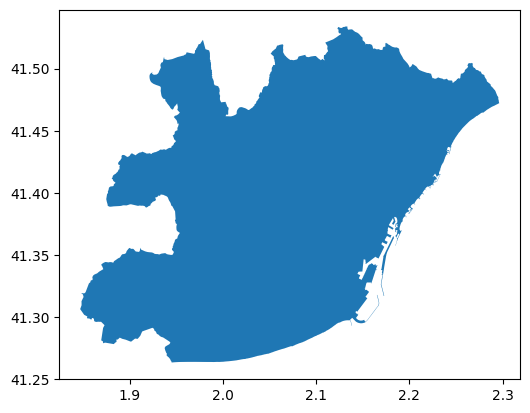

In [2]:
# Importing osmnx

# Define the polygon for the 1st district of Budapest
admin_district = ox.geocode_to_gdf('Àrea Metropolitana de Barcelona, Spain')
admin_district.plot()
admin_poly = admin_district.geometry.values[0]

# Load the graph from OSMnx
G = ox.graph_from_polygon(admin_poly, network_type='walk')

print('Number of intersections: ', G.number_of_nodes())
print('Number of road segments:',  G.number_of_edges())

In [3]:
neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)
neigh = neigh[["name", "geometry"]]
neigh["geometry"] = neigh.buffer(0)


neigh_layer = alt.Chart(neigh).mark_geoshape(
    stroke="black",
    fill="lightblue"
).properties(
    width=600,
    height=600
    
).encode(tooltip=['name'])

In [4]:
metro_sol = pd.read_csv('Nodes/Bus-Sol.csv')
metro = pd.read_csv('Nodes/Bus.csv')

all_stops = pd.concat([metro_sol, metro], ignore_index=True)
all_stops['geometry']= all_stops['geometry'].apply(wkt.loads)
all_stops = gpd.GeoDataFrame(all_stops, geometry='geometry', crs="EPSG:4326")


In [24]:
bus_sol = pd.read_csv('Nodes/Bus-Sol.csv')
bus = pd.read_csv('Nodes/Bus.csv')
fgc_sol = pd.read_csv('Nodes/FGC-Sol.csv')
fgc = pd.read_csv('Nodes/FGC.csv')
metro_sol = pd.read_csv('Nodes/Metro-Sol.csv')
metro = pd.read_csv('Nodes/Metro.csv')
tram_sol = pd.read_csv('Nodes/Tram-Sol.csv')
tram = pd.read_csv('Nodes/Tram.csv')
destinations = pd.read_csv('Nodes/Destinations.csv')

all_stops = pd.concat([bus_sol, bus, fgc_sol, fgc, metro_sol, metro, tram_sol, tram], ignore_index=True)
all_stops['geometry']= all_stops['geometry'].apply(wkt.loads)
all_stops = gpd.GeoDataFrame(all_stops, geometry='geometry', crs="EPSG:4326")
#all_stops = all_stops[:100]


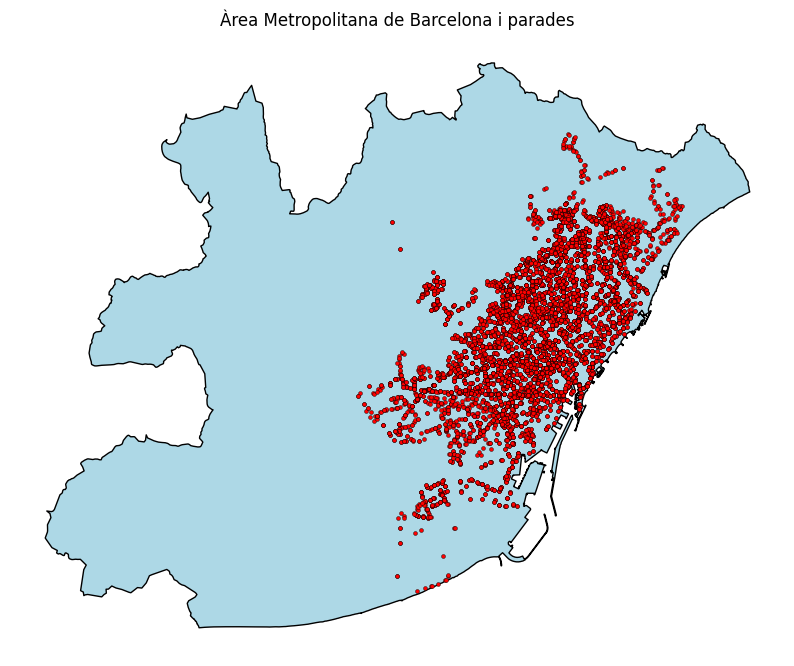

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))

admin_district.plot(
    ax=ax,
    color="lightblue",
    edgecolor="black",
    linewidth=1
)

all_stops.plot(
    ax=ax,
    color="red",
    markersize=8,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("Àrea Metropolitana de Barcelona i parades")
ax.axis("off")
plt.show()

In [6]:
walking_speed = 1.39

for u, v, data in G.edges(data=True):
    data["travel_time"] = data["length"] / walking_speed


isochrone_time = 5
isochrone_polys = []

process = 1
for stop in all_stops['stop_id'].unique():
    print(f"Processing stop {stop} ({process}/{len(all_stops['stop_id'].unique())})")
    process += 1
    p = all_stops[all_stops['stop_id'] == stop].iloc[0]
    center_node = ox.distance.nearest_nodes(G, X=p['geometry'].x, Y=p["geometry"].y)

    subgraph = nx.ego_graph(
            G,
            center_node,
            radius= isochrone_time * 60,
            distance="travel_time"
        )

    node_points = [
        Point((data["x"], data["y"]))
        for node, data in subgraph.nodes(data=True)
    ]

    center_point = Point(G.nodes[center_node]["x"], G.nodes[center_node]["y"])

    polygon = gpd.GeoSeries(node_points).union_all().convex_hull
    isochrone_polys.append(
            gpd.GeoDataFrame(
                {"stop_id": [p["stop_id"]], "geometry": [polygon]},
                crs="EPSG:4326"
            )
        )

isochrone_polys = gpd.GeoDataFrame(pd.concat(isochrone_polys, ignore_index=True), crs="EPSG:4326")

Processing stop 2 (1/3342)
Processing stop 3 (2/3342)
Processing stop 4 (3/3342)
Processing stop 7 (4/3342)
Processing stop 8 (5/3342)
Processing stop 12 (6/3342)
Processing stop 13 (7/3342)
Processing stop 15 (8/3342)
Processing stop 16 (9/3342)
Processing stop 17 (10/3342)
Processing stop 18 (11/3342)
Processing stop 20 (12/3342)
Processing stop 21 (13/3342)
Processing stop 22 (14/3342)
Processing stop 24 (15/3342)
Processing stop 25 (16/3342)
Processing stop 27 (17/3342)
Processing stop 28 (18/3342)
Processing stop 29 (19/3342)
Processing stop 30 (20/3342)
Processing stop 31 (21/3342)
Processing stop 32 (22/3342)
Processing stop 34 (23/3342)
Processing stop 36 (24/3342)
Processing stop 38 (25/3342)
Processing stop 39 (26/3342)
Processing stop 41 (27/3342)
Processing stop 42 (28/3342)
Processing stop 43 (29/3342)
Processing stop 44 (30/3342)
Processing stop 47 (31/3342)
Processing stop 48 (32/3342)
Processing stop 51 (33/3342)
Processing stop 52 (34/3342)
Processing stop 54 (35/3342)

In [7]:
isocores_df_all = all_stops[all_stops['stop_id'].isin(isochrone_polys['stop_id'].unique())].merge(isochrone_polys, on='stop_id', how='left')
isocores_df_all.drop(columns=['geometry_x'], inplace=True)
isocores_df_all.rename(columns={'geometry_y': 'geometry'}, inplace=True)
isocores_df_all.set_geometry('geometry', inplace=True)
isocores_df_all

,id,stop_id,name,linia,stop_type,geometry
0,SB-2,2,Av Icària - Àlaba,IU Stop,Bus,"POLYGON ((2.19864 41.39029, 2.19655 41.39061, ..."
1,SB-3,3,València - Muntaner,IU Stop,Bus,"POLYGON ((2.15827 41.38549, 2.15633 41.38565, ..."
2,SB-4,4,Mallorca - Balmes,IU Stop,Bus,"POLYGON ((2.15993 41.38804, 2.15929 41.38809, ..."
3,SB-7,7,Pl Universitat,IU Stop,Bus,"POLYGON ((2.16361 41.38233, 2.15976 41.38319, ..."
4,SB-8,8,Pl de Carles Buïgas,IU Stop,Bus,"POLYGON ((2.15159 41.36902, 2.14665 41.36923, ..."
...,...,...,...,...,...,...
8531,T-T5-STJB,STJB,Sant Joan Baptista,T5,Tram,"POLYGON ((2.22446 41.42451, 2.22411 41.42458, ..."
8532,T-T5-NKNS,NKNS,Encants de Sant Adrià,T5,Tram,"POLYGON ((2.21987 41.42728, 2.21921 41.42804, ..."
8533,T-T5-STRC,STRC,Sant Roc,T5,Tram,"POLYGON ((2.22644 41.43243, 2.22467 41.43269, ..."
8534,T-T5-GORG,GORG,Gorg,T5,Tram,"POLYGON ((2.23004 41.43745, 2.22926 41.43984, ..."


In [8]:
isocores_df_all.to_csv('Data/Neigh/isochrones_df-csv',index= False)

In [15]:
isocores_df_all = pd.read_csv('Data/Neigh/isochrones_df-csv')
isocores_df_all['geometry'] = isocores_df_all['geometry'].apply(wkt.loads)
isocores_df_all = gpd.GeoDataFrame(isocores_df_all,geometry='geometry',crs = 'EPSG:4326')
isocores_df_all

,id,stop_id,name,linia,stop_type,geometry
0,SB-2,2,Av Icària - Àlaba,IU Stop,Bus,"POLYGON ((2.19864 41.39029, 2.19655 41.39061, ..."
1,SB-3,3,València - Muntaner,IU Stop,Bus,"POLYGON ((2.15827 41.38549, 2.15633 41.38565, ..."
2,SB-4,4,Mallorca - Balmes,IU Stop,Bus,"POLYGON ((2.15993 41.38804, 2.15929 41.38809, ..."
3,SB-7,7,Pl Universitat,IU Stop,Bus,"POLYGON ((2.16361 41.38233, 2.15976 41.38319, ..."
4,SB-8,8,Pl de Carles Buïgas,IU Stop,Bus,"POLYGON ((2.15159 41.36902, 2.14665 41.36923, ..."
...,...,...,...,...,...,...
8531,T-T5-STJB,STJB,Sant Joan Baptista,T5,Tram,"POLYGON ((2.22446 41.42451, 2.22411 41.42458, ..."
8532,T-T5-NKNS,NKNS,Encants de Sant Adrià,T5,Tram,"POLYGON ((2.21987 41.42728, 2.21921 41.42804, ..."
8533,T-T5-STRC,STRC,Sant Roc,T5,Tram,"POLYGON ((2.22644 41.43243, 2.22467 41.43269, ..."
8534,T-T5-GORG,GORG,Gorg,T5,Tram,"POLYGON ((2.23004 41.43745, 2.22926 41.43984, ..."


In [42]:
isos = alt.Chart(isocores_df_all).mark_geoshape(
    stroke="black",
    fill="gray",
    opacity = 0.3
).properties(
    width=600,
    height=600
    
).encode(tooltip=['name'])

destinations = pd.read_csv('Nodes/Destinations.csv')
destinations['geometry'] = destinations['geometry'].apply(wkt.loads)
destinations = gpd.GeoDataFrame(destinations,geometry='geometry',crs = 'EPSG:4326')


point = alt.Chart(destinations[destinations['poi_name'] == 'Zona Universitària']).mark_geoshape(size = 0)

isos +point


alt.LayerChart(...)

In [45]:
pois = pd.read_csv('Nodes/Destinations.csv')
pois['geometry'] = pois['geometry'].apply(wkt.loads)
pois = gpd.GeoDataFrame(pois,geometry='geometry',crs = 'EPSG:4326')
isocores_df_all_merge = isocores_df_all.copy()
pois.to_crs('EPSG:25831', inplace=True)
isocores_df_all_merge.to_crs('EPSG:25831', inplace=True)
isocores_df_all_merge.rename(columns={'id': 'origin_id','stop_id':'origin_stop_id','name':'origin_stop_name','linia':'linia','stop_type':'origin_stop_type'}, inplace=True)
close_destinations = gpd.sjoin(pois,isocores_df_all_merge, how='inner', predicate='within')
close_destinations.drop(columns = ['index_right','category'],inplace = True)
close_destinations = close_destinations[['origin_id', 'origin_stop_id','origin_stop_name', 'origin_stop_type', 'linia', 'poi_name']]
close_destinations['tram'] = close_destinations['origin_stop_name'] + ' - ' + close_destinations['poi_name']
close_destinations

,origin_id,origin_stop_id,origin_stop_name,origin_stop_type,linia,poi_name,tram
0,SB-296,296,Av Doctor Marañón - Baldiri i Reixac,Bus,IU Stop,Zona Universitària,Av Doctor Marañón - Baldiri i Reixac - Zona Un...
0,SB-1650,1650,Av Doctor Marañón - Av de Xile,Bus,IU Stop,Zona Universitària,Av Doctor Marañón - Av de Xile - Zona Universi...
0,SB-3233,3233,ETS d'Arquitectura,Bus,IU Stop,Zona Universitària,ETS d'Arquitectura - Zona Universitària
0,B-V1-296,296,Av Doctor Marañón - Baldiri i Reixac,Bus,V1,Zona Universitària,Av Doctor Marañón - Baldiri i Reixac - Zona Un...
0,B-113-1650,1650,Av Doctor Marañón - Av de Xile,Bus,113,Zona Universitària,Av Doctor Marañón - Av de Xile - Zona Universi...
...,...,...,...,...,...,...,...
24,B-V21-915,915,Vila Olímpica,Bus,V21,Parc de Recerca Biomèdica,Vila Olímpica - Parc de Recerca Biomèdica
24,B-V27-915,915,Vila Olímpica,Bus,V27,Parc de Recerca Biomèdica,Vila Olímpica - Parc de Recerca Biomèdica
24,B-136-915,915,Vila Olímpica,Bus,136,Parc de Recerca Biomèdica,Vila Olímpica - Parc de Recerca Biomèdica
24,B-D20-1788,1788,Trelawny - Av Litoral,Bus,D20,Parc de Recerca Biomèdica,Trelawny - Av Litoral - Parc de Recerca Biomèdica


In [11]:
# cache_dir = Config().CACHE_DIR
# for f in cache_dir.glob("*.mapdb*"):
#     f.unlink()

In [43]:
transport_network = r5py.TransportNetwork(
    "Data/Neigh/cataluna-260811.osm.pbf",
    elevation_model =["Data/Neigh/elevacions-terreny-lidar-Catalunya-2m-2008-2011tif1786456535055.tif"]
    )

In [65]:
all_stops[all_stops['stop_id'] == '296']


,id,stop_id,name,linia,stop_type,geometry


In [ ]:
stops[]

origin_id           object
origin_stop_id      object
origin_stop_name    object
origin_stop_type    object
linia               object
poi_name            object
tram                object
dtype: object

In [ ]:
pois

,id,stop_id,name,linia,stop_type,geometry
185,SB-296,296,Av Doctor Marañón - Baldiri i Reixac,IU Stop,Bus,POINT (2.11396 41.38205)


In [77]:
itineraries = pd.DataFrame()
process = 0
failed_iteraries = []
all_stops['stop_id'] = all_stops['stop_id'].astype(str)
pois.to_crs("EPSG:4326",inplace=True)

for stop in close_destinations['origin_stop_id'].unique():
    process += 1
    print(f"Processing {process}/{close_destinations['origin_stop_id'].nunique()}")
    stops = close_destinations[close_destinations['origin_stop_id'] == stop]
    stops.drop_duplicates(subset=['origin_stop_id', 'poi_name'], inplace=True)

    for _, row in stops.iterrows():
        origin_id = row['origin_stop_id']
        poi  = row['poi_name']

        # if origin_id  != 342:
        #     continue
        # if destination_id != 2:
        #     continue

        # if process != 2374:
        #     continue
        origins = all_stops[all_stops['stop_id'] == origin_id]
        origins.drop_duplicates(subset=['stop_id'], inplace=True)
        origins.rename(columns={'origin_id': 'id'}, inplace=True)
        destinations = pois[pois['poi_name'] == poi].copy()
        print(destinations)
        destinations.rename(columns={'poi_name': 'id'}, inplace=True)
        origins = gpd.GeoDataFrame(origins, geometry='geometry', crs="EPSG:4326")
        destinations = gpd.GeoDataFrame(destinations, geometry='geometry', crs="EPSG:4326")
        detailed_itineraries = r5py.DetailedItineraries(
            transport_network,
            origins=origins,
            destinations=destinations,
            transport_modes=[r5py.TransportMode.WALK],
            snap_to_network=True,
            speed_walking = 5,
            departure=datetime.datetime(2026, 5, 13, 9, 30),

        )

        if len(detailed_itineraries) == 0:
            failed_iteraries.append((origin_id, poi))
            continue
        exchange_time = detailed_itineraries['travel_time'].sum()
        itineraries_row = pd.DataFrame({
            'origin_stop_id': [origin_id],
            'poi_name': [poi],
            'time': [exchange_time],
            'geometry': [detailed_itineraries['geometry'].iloc[0]],
        })

        itineraries_row = gpd.GeoDataFrame(itineraries_row, geometry='geometry', crs="EPSG:4326")
        itineraries = pd.concat([itineraries, itineraries_row], ignore_index=True)


itineraries["time"] = itineraries["time"].apply(
    lambda x: f"{int(x.total_seconds() // 60):02d}:{int(x.total_seconds() % 60):02d}"
)


Processing 1/185
             poi_name    category                  geometry  demand
0  Zona Universitària  university  POINT (2.11406 41.38275)     202
Processing 2/185
             poi_name    category                  geometry  demand
0  Zona Universitària  university  POINT (2.11406 41.38275)     202
Processing 3/185
             poi_name    category                  geometry  demand
0  Zona Universitària  university  POINT (2.11406 41.38275)     202
                     poi_name  category               geometry  demand
21  Hospital Sant Joan de Déu  hospital  POINT (2.112 41.3855)     408
Processing 4/185
             poi_name    category                  geometry  demand
0  Zona Universitària  university  POINT (2.11406 41.38275)     202
                     poi_name  category               geometry  demand
21  Hospital Sant Joan de Déu  hospital  POINT (2.112 41.3855)     408
Processing 5/185
             poi_name    category                  geometry  demand
0  Zona Universitàr

In [78]:
itineraries

,origin_stop_id,poi_name,time,geometry
0,296,Zona Universitària,02:25,"LINESTRING (2.11468 41.38166, 2.11448 41.38177..."
1,1650,Zona Universitària,03:43,"LINESTRING (2.11484 41.38123, 2.11443 41.38144..."
2,3233,Zona Universitària,02:56,"LINESTRING (2.11401 41.38484, 2.11396 41.38482..."
3,3233,Hospital Sant Joan de Déu,05:12,"LINESTRING (2.11401 41.38484, 2.11396 41.38482..."
4,UNIV,Zona Universitària,02:00,"LINESTRING (2.11419 41.38466, 2.11443 41.38412..."
...,...,...,...,...
196,104244,Barcelona Science Park,06:20,"MULTILINESTRING ((2.11408 41.36359, 2.11482 41..."
197,104245,Barcelona Science Park,06:26,"MULTILINESTRING ((2.11412 41.36364, 2.11505 41..."
198,106870,Barcelona Science Park,03:49,"LINESTRING (2.11851 41.35994, 2.11848 41.35997..."
199,915,Parc de Recerca Biomèdica,02:49,"LINESTRING (2.19417 41.38882, 2.19369 41.38842..."


In [79]:
close_destinations

,origin_id,origin_stop_id,origin_stop_name,origin_stop_type,linia,poi_name,tram
0,SB-296,296,Av Doctor Marañón - Baldiri i Reixac,Bus,IU Stop,Zona Universitària,Av Doctor Marañón - Baldiri i Reixac - Zona Un...
0,SB-1650,1650,Av Doctor Marañón - Av de Xile,Bus,IU Stop,Zona Universitària,Av Doctor Marañón - Av de Xile - Zona Universi...
0,SB-3233,3233,ETS d'Arquitectura,Bus,IU Stop,Zona Universitària,ETS d'Arquitectura - Zona Universitària
0,B-V1-296,296,Av Doctor Marañón - Baldiri i Reixac,Bus,V1,Zona Universitària,Av Doctor Marañón - Baldiri i Reixac - Zona Un...
0,B-113-1650,1650,Av Doctor Marañón - Av de Xile,Bus,113,Zona Universitària,Av Doctor Marañón - Av de Xile - Zona Universi...
...,...,...,...,...,...,...,...
24,B-V21-915,915,Vila Olímpica,Bus,V21,Parc de Recerca Biomèdica,Vila Olímpica - Parc de Recerca Biomèdica
24,B-V27-915,915,Vila Olímpica,Bus,V27,Parc de Recerca Biomèdica,Vila Olímpica - Parc de Recerca Biomèdica
24,B-136-915,915,Vila Olímpica,Bus,136,Parc de Recerca Biomèdica,Vila Olímpica - Parc de Recerca Biomèdica
24,B-D20-1788,1788,Trelawny - Av Litoral,Bus,D20,Parc de Recerca Biomèdica,Trelawny - Av Litoral - Parc de Recerca Biomèdica


In [88]:
itineraries_final = close_destinations.merge(itineraries, on=['origin_stop_id', 'poi_name'], how='left')
itineraries_final.drop(columns=['origin_stop_id','origin_stop_type','origin_stop_name'], inplace=True)
itineraries_final.rename(columns={'origin_id':'origen','poi_name':'dest','linia':'last_line'},inplace=True)
itineraries_final = itineraries_final[['origen','dest','tram','last_line','time','geometry']]
itineraries_final.insert(4, 'type', 'Egress')
itineraries_final.insert(6, 'directed', True)
itineraries_final

,origen,dest,tram,last_line,type,time,directed,geometry
0,SB-296,Zona Universitària,Av Doctor Marañón - Baldiri i Reixac - Zona Un...,IU Stop,Egress,02:25,True,"LINESTRING (2.11468 41.38166, 2.11448 41.38177..."
1,SB-1650,Zona Universitària,Av Doctor Marañón - Av de Xile - Zona Universi...,IU Stop,Egress,03:43,True,"LINESTRING (2.11484 41.38123, 2.11443 41.38144..."
2,SB-3233,Zona Universitària,ETS d'Arquitectura - Zona Universitària,IU Stop,Egress,02:56,True,"LINESTRING (2.11401 41.38484, 2.11396 41.38482..."
3,B-V1-296,Zona Universitària,Av Doctor Marañón - Baldiri i Reixac - Zona Un...,V1,Egress,02:25,True,"LINESTRING (2.11468 41.38166, 2.11448 41.38177..."
4,B-113-1650,Zona Universitària,Av Doctor Marañón - Av de Xile - Zona Universi...,113,Egress,03:43,True,"LINESTRING (2.11484 41.38123, 2.11443 41.38144..."
...,...,...,...,...,...,...,...,...
637,B-V21-915,Parc de Recerca Biomèdica,Vila Olímpica - Parc de Recerca Biomèdica,V21,Egress,02:49,True,"LINESTRING (2.19417 41.38882, 2.19369 41.38842..."
638,B-V27-915,Parc de Recerca Biomèdica,Vila Olímpica - Parc de Recerca Biomèdica,V27,Egress,02:49,True,"LINESTRING (2.19417 41.38882, 2.19369 41.38842..."
639,B-136-915,Parc de Recerca Biomèdica,Vila Olímpica - Parc de Recerca Biomèdica,136,Egress,02:49,True,"LINESTRING (2.19417 41.38882, 2.19369 41.38842..."
640,B-D20-1788,Parc de Recerca Biomèdica,Trelawny - Av Litoral - Parc de Recerca Biomèdica,D20,Egress,06:43,True,"LINESTRING (2.19507 41.38535, 2.19468 41.38565..."


In [89]:
itineraries_final['time'].sum()

'02:2503:4302:5602:2503:4303:4302:5602:0005:1002:0002:0002:0005:1005:1005:1002:3103:2304:1204:1802:0104:4400:3105:3002:3102:3102:3103:2303:2303:2303:2303:2304:1204:1204:1204:1802:0102:0104:4404:4400:3100:3100:3100:3105:3005:3005:3002:3102:3104:4704:1502:1004:5700:5003:3602:3804:4704:4704:1502:1002:1002:1002:1004:5700:5003:3602:3803:0106:4308:0402:1606:0505:1804:0205:0105:4307:4604:3803:0103:0106:4306:4306:4308:0408:0408:0408:0402:1602:1602:1602:1606:0506:0505:1805:1805:1804:0204:0204:0204:0204:0204:0205:0105:0105:0105:4305:4305:4305:4305:4305:4307:4604:3802:1602:1601:4403:3404:1301:4403:3404:1305:1101:5902:2105:3305:1105:1101:5901:5901:5902:2102:2102:2105:3305:3305:1502:5205:0803:3805:2604:2604:3604:5805:1505:1505:1502:5202:5202:5202:5205:0805:0805:0803:3803:3803:3803:3803:3805:2604:2604:3604:5801:5104:1004:4104:1204:3204:4602:1005:3204:0501:5104:1004:4104:1204:3204:3204:3204:3204:4602:1005:3204:0502:0602:0504:4705:5804:1805:2403:4104:2002:0602:0602:0602:0602:0502:0504:4705:5805:5805:5

In [23]:
all_exchanges = pd.concat([same_stops, different_stops], ignore_index=True)
all_exchanges.rename(columns={'origin_id': 'origen', 'destination_id': 'dest','exchange_time':'time'}, inplace=True)
all_exchanges = gpd.GeoDataFrame(all_exchanges, geometry='geometry', crs="EPSG:4326")
all_exchanges = all_exchanges[all_exchanges['time'] <= '05:00']
all_exchanges.insert(7, 'directed', True)

In [24]:
all_exchanges.to_csv('Nodes/Exchanges.csv', index=False)

In [18]:
# Frame 1: polygons only
isochrone_chart = alt.Chart(isocores_df_all[isocores_df_all['stop_id'].isin([2575])]).mark_geoshape(
    stroke='black',
    strokeWidth=1
).encode(tooltip=['id'])

points = alt.Chart(all_stops[all_stops['stop_id'].isin([2575,84])]).mark_geoshape(
    fill='red',
    stroke='black',
    strokeWidth=1,
    size=0
).encode(
    tooltip=['name']
)

itineraries_chart = alt.Chart(all_exchanges[all_exchanges['origen'].isin(['B-B80-2575']) & (all_exchanges['dest'].isin(['B-B18-84']))]).mark_geoshape(
    filled = False,
    stroke='black',
    strokeWidth=1,
    size=0
)


(
isochrone_chart + points + itineraries_chart  ).properties(
    width=900,
    height=900
)

alt.LayerChart(...)

In [ ]:
# Frame 1: polygons only
polys_df = isocores_df_all[['id', 'geometry']].copy()
polys_df = gpd.GeoDataFrame(polys_df, geometry='geometry', crs="EPSG:4326")


not_self_exchanges = all_exchanges[all_exchanges['type'] == 'Exchange'].copy()
#not_self_exchanges = not_self_exchanges[not_self_exchanges['mode'] == 'Bus - Tram']
origens = not_self_exchanges['origen'].unique().tolist()
destinations = not_self_exchanges['dest'].unique().tolist()
stops =  origens + destinations

isochrone_chart = alt.Chart(polys_df[polys_df['id'].isin(origens)]).mark_geoshape(
    stroke='black',
    strokeWidth=1
).encode(tooltip=['id'])

points = alt.Chart(all_stops[all_stops['id'].isin(stops)]).mark_geoshape(
    fill='red',
    stroke='black',
    strokeWidth=1,
    size=0
).encode(
    tooltip=['name']
)

itineraries_chart = alt.Chart(not_self_exchanges).mark_geoshape(
    filled = False,
    stroke='black',
    strokeWidth=1,
    size=0
)


(
neigh_layer + isochrone_chart).properties(
    width=900,
    height=900
)

MaxRowsError: The number of rows in your dataset (8390) is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.LayerChart(...)

In [ ]:



# ---------------------------------------------------------
# Load neighbourhoods
# ---------------------------------------------------------

neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)

neigh = neigh[["name", "geometry"]]

neigh["geometry"] = neigh.geometry.buffer(0)


# ---------------------------------------------------------
# Prepare itinerary data
# ---------------------------------------------------------

itineraries["mode"] = itineraries["transport_mode"].astype(str)

itineraries["travel time (min)"] = itineraries["travel_time"].apply(
    lambda t: round(t.total_seconds() / 60.0, 2)
)

itineraries["trip"] = itineraries.apply(
    lambda row: f"{row['from_id']} → {row['to_id']}",
    axis=1
)


# ---------------------------------------------------------
# Create map
# ---------------------------------------------------------



detailed_routes_map = (
    itineraries[
        [
            "geometry",
            "distance",
            "mode",
            "travel time (min)",
            "from_id",
            "to_id",
            "trip",
            "option",
            "segment",
        ]
    ]
    .explore(
        tooltip=[
            "trip",
            "option",
            "segment",
            "mode",
            "travel time (min)",
            "distance",
        ],
        column="mode",
        tiles="CartoDB.Positron",
        style_kwds={
            "weight": 3,
            "opacity": 0.8,
        },
        highlight_kwds={
            "weight": 6,
            "opacity": 1,
        },
    )
)


isochrone_polys.explore(
    m=detailed_routes_map,
    tooltip=["stop_id"],
    style_kwds={
        "fillOpacity": 0.15,
        "weight": 1,
    },
)

# ---------------------------------------------------------
# Get stops involved in the itineraries
# ---------------------------------------------------------

stop_ids = pd.unique(
    pd.concat([
        itineraries["from_id"],
        itineraries["to_id"]
    ])
)

stops_map = all_stops[
    all_stops["id"].isin(stop_ids)
].copy()

stops_map = gpd.GeoDataFrame(
    stops_map,
    geometry="geometry",
    crs="EPSG:4326"
)


# ---------------------------------------------------------
# Assign neighbourhood to each stop
# ---------------------------------------------------------

# Project both layers for the spatial join
stops_projected = stops_map.to_crs("EPSG:25831")
neigh_projected = neigh.to_crs("EPSG:25831")

stops_map = gpd.sjoin(
    stops_projected,
    neigh_projected[["name", "geometry"]],
    how="left",
    predicate="within"
)

# Return to WGS84 for Folium
stops_map = stops_map.to_crs("EPSG:4326")


# ---------------------------------------------------------
# Add stop markers
# ---------------------------------------------------------

stops_map.apply(
    lambda row: folium.Marker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        tooltip=(
            f"Stop: {row['id']}<br>"
        ),
        icon=folium.plugins.BeautifyIcon(
            icon_shape="marker",
            number=str(row["id"]),
            border_color="#728224",
            text_color="#728224",
        ),
    ).add_to(detailed_routes_map),
    axis=1,
)


detailed_routes_map